In [1]:
from pathlib import Path
import json
import os
import re

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

### MAOMAO — Illustrative quantitative activity regression

This notebook demonstrates quantitative reuse of MAOMAO activity measurements reported as:

- `HC50`;
- `LC50`;
- `LD50`;
- `MHC`.

The current MAOMAO parsing workflow exports endpoint-specific regression datasets such as:

```text
processed_HC50_dataset.csv
processed_LC50_dataset.csv
processed_LD50_dataset.csv
processed_MHC_dataset.csv
```

with quantitative `label` values and standardized `unit` fields. Modified peptide variants are exported separately and are **not included by default** in this demonstration.

The workflow below:

1. discovers released quantitative endpoint datasets;
2. inventories endpoint/unit coverage;
3. selects one homogeneous endpoint + unit group;
4. maps peptide sequences back to stable MAOMAO IDs through the master pivot;
5. aggregates repeated measurements per exact sequence using the median;
6. reuses one released PLM representation;
7. applies a `log10` target transform to strictly positive measurements;
8. compares a median baseline with a simple Ridge regression model;
9. reports MAE, RMSE, R², and Spearman correlation.

This is a **quantitative reuse example, not a validated activity-prediction benchmark**.


## Why endpoint and unit homogeneity matters

`HC50`, `LC50`, `LD50`, and `MHC` are different experimental endpoints. Likewise, values reported in different measurement units should not be pooled numerically without an explicit, scientifically justified conversion.

Therefore this notebook does **not** merge all activity values into one regression target. It selects a single endpoint and unit combination with sufficient data.


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
MINIMUM_UNIQUE_SEQUENCES = 20

# Optional manual selection. Leave as None to choose the largest eligible group.
ENDPOINT_OVERRIDE = None
UNIT_OVERRIDE = None

## 1. Locate MAOMAO and configure outputs


In [3]:
MAOMAO_ROOT_OVERRIDE = None
OUTPUT_ROOT_OVERRIDE = None
RESULTS_DIRECTORY_NAME = "results_how_to_use_maomao"

PIVOT_RELATIVE_PATHS = [
    Path("processed_data/processed_data/maomao_sequence_pivot.csv"),
    Path("core_layer/processed_data/processed_data/maomao_sequence_pivot.csv"),
]

def candidate_roots(override=None):
    candidates = []
    if override is not None:
        candidates.append(Path(override).expanduser())

    env_root = os.environ.get("MAOMAO_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())

    cwd = Path.cwd()
    candidates.extend([cwd, *list(cwd.parents)[:4]])
    candidates.extend([
        cwd / "downloads" / "maomao_release",
        cwd.parent / "downloads" / "maomao_release",
    ])

    unique = []
    seen = set()
    for path in candidates:
        try:
            resolved = path.resolve()
        except FileNotFoundError:
            resolved = path.absolute()
        if resolved not in seen:
            seen.add(resolved)
            unique.append(resolved)
    return unique

def resolve_maomao_root(override=None):
    checked = []
    for root in candidate_roots(override):
        for rel in PIVOT_RELATIVE_PATHS:
            candidate = root / rel
            checked.append(candidate)
            if candidate.is_file():
                return root, candidate

    preview = "\n".join(f" - {p}" for p in checked[:25])
    raise FileNotFoundError(
        "Could not locate maomao_sequence_pivot.csv.\n"
        "Set MAOMAO_ROOT or MAOMAO_ROOT_OVERRIDE to the MAOMAO repository "
        "or extracted Zenodo release root.\n\n"
        f"Checked examples:\n{preview}"
    )

def resolve_output_root(maomao_root):
    if OUTPUT_ROOT_OVERRIDE is not None:
        return Path(OUTPUT_ROOT_OVERRIDE).expanduser().resolve()
    return Path(maomao_root).resolve() / RESULTS_DIRECTORY_NAME

MAOMAO_ROOT, PIVOT_PATH = resolve_maomao_root(MAOMAO_ROOT_OVERRIDE)
OUTPUT_ROOT = resolve_output_root(MAOMAO_ROOT)

print("MAOMAO root :", MAOMAO_ROOT)
print("Master pivot:", PIVOT_PATH)
print("Output root :", OUTPUT_ROOT)

MAOMAO root : /home/nicole/Descargas/maomao
Master pivot: /home/nicole/Descargas/maomao/processed_data/processed_data/maomao_sequence_pivot.csv
Output root : /home/nicole/Descargas/maomao/results_how_to_use_maomao


In [4]:
OUTPUT_DIR = OUTPUT_ROOT / "03_quantitative_activity_regression"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook output directory:", OUTPUT_DIR)


Notebook output directory: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression


In [5]:
COLORS = {
    "toxic": "#C5A3B0",
    "cytotoxic": "#CEC4DE",
    "neurotoxic": "#CEC4DE",
    "embryotoxic": "#CEC4DE",
    "ichthyotoxic": "#CEC4DE",
    "hemolytic": "#DEB089",
    "cytolysis": "#DEB089",
    "anti_mammalian_cells": "#DEB089",
}

QUANTITATIVE_COLORS = {
    "HC50": COLORS["hemolytic"],
    "LC50": COLORS["toxic"],
    "LD50": "#A7748E",
    "MHC": "#E7C6A8",
}

TEXT_COLOR = "#4D414C"
EDGE_COLOR = "#735F6C"
GRID_COLOR = "#EAE5EA"
MAOMAO_CMAP = LinearSegmentedColormap.from_list(
    "maomao_mauve",
    ["#F8F5F7", "#E5DCE8", "#CEC4DE", "#C5A3B0", "#8E6179"],
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlecolor": TEXT_COLOR,
    "axes.labelsize": 10.5,
    "axes.labelcolor": TEXT_COLOR,
    "axes.edgecolor": "#BDB3BC",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def style_axes(ax, grid_axis="y"):
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8)
    ax.spines["left"].set_color("#BDB3BC")
    ax.spines["bottom"].set_color("#BDB3BC")
    ax.tick_params(length=3, width=0.7)


def save_figure(fig, stem):
    png = FIGURE_DIR / f"{stem}.png"
    pdf = FIGURE_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0.08)
    fig.savefig(pdf, bbox_inches="tight", pad_inches=0.08)
    print("Saved:", png)
    print("Saved:", pdf)

## 2. Load the master pivot for stable sequence-to-ID mapping


In [6]:
maomao = pd.read_csv(PIVOT_PATH, usecols=["id", "sequence"])

maomao["id"] = maomao["id"].astype(str)
maomao["sequence"] = (
    maomao["sequence"]
    .astype(str)
    .str.strip()
    .str.upper()
)

if maomao["id"].duplicated().any():
    raise ValueError("Duplicate MAOMAO IDs detected in the master pivot.")

sequence_to_id = maomao.drop_duplicates(subset="sequence")[["sequence", "id"]]

print(f"Master peptide entities: {len(maomao):,}")
print(f"Unique exact sequences  : {sequence_to_id['sequence'].nunique():,}")


Master peptide entities: 71,857
Unique exact sequences  : 71,857


## 3. Discover released quantitative activity datasets

The discovery rule intentionally selects only files named `processed_<ENDPOINT>_dataset.csv`.

Files named `modified_<ENDPOINT>_dataset.csv` remain outside this default demonstration because modified peptide identity may depend on both sequence and modification annotation.


In [7]:
QUANTITATIVE_ENDPOINTS = {"HC50", "LC50", "LD50", "MHC"}

search_roots = [
    MAOMAO_ROOT / "processed_data",
    MAOMAO_ROOT / "core_layer" / "processed_data",
]

dataset_rows = []

for search_root in search_roots:
    if not search_root.is_dir():
        continue

    for path in search_root.rglob("processed_*_dataset.csv"):
        match = re.fullmatch(
            r"processed_(HC50|LC50|LD50|MHC)_dataset\.csv",
            path.name,
            flags=re.IGNORECASE,
        )
        if not match:
            continue

        endpoint = match.group(1).upper()

        try:
            header = pd.read_csv(path, nrows=0)
        except Exception:
            continue

        required = {"sequence", "label", "unit"}
        if not required.issubset(header.columns):
            continue

        dataset_rows.append({
            "endpoint": endpoint,
            "path": str(path),
            "source_directory": path.parent.name,
        })

dataset_inventory = pd.DataFrame(dataset_rows).drop_duplicates()

if dataset_inventory.empty:
    raise FileNotFoundError(
        "No processed HC50/LC50/LD50/MHC datasets were found. "
        "The current parsing workflow exports files named "
        "processed_<ENDPOINT>_dataset.csv under toxic_effect_regression source directories."
    )

display(dataset_inventory)
dataset_inventory.to_csv(
    TABLE_DIR / "quantitative_dataset_inventory.tsv",
    sep="\t",
    index=False,
)


,endpoint,path,source_directory
0,LD50,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,Hemolytik2.0_2026
1,MHC,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_MHC_dataset.csv,Hemolytik2.0_2026
2,LC50,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LC50_dataset.csv,Hemolytik2.0_2026
3,HC50,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_HC50_dataset.csv,Hemolytik2.0_2026


## 4. Integrate non-modified quantitative records for characterization


In [8]:
activity_parts = []

for row in dataset_inventory.itertuples(index=False):
    frame = pd.read_csv(row.path)
    frame["endpoint"] = row.endpoint
    frame["source_directory"] = row.source_directory
    frame["source_file"] = row.path

    if "source" not in frame.columns:
        frame["source"] = row.source_directory

    keep = [
        col for col in [
            "sequence", "source", "label", "unit",
            "endpoint", "source_directory", "source_file",
        ]
        if col in frame.columns
    ]

    activity_parts.append(frame[keep].copy())

activity = pd.concat(activity_parts, ignore_index=True)

activity["sequence"] = (
    activity["sequence"]
    .astype(str)
    .str.strip()
    .str.upper()
)
activity["unit"] = activity["unit"].astype(str).str.strip()
activity["label_numeric"] = pd.to_numeric(activity["label"], errors="coerce")

activity["valid_numeric_target"] = (
    activity["label_numeric"].notna()
    & np.isfinite(activity["label_numeric"])
    & activity["label_numeric"].gt(0)
    & activity["unit"].ne("")
    & activity["unit"].str.lower().ne("nan")
)

print(f"Discovered quantitative rows : {len(activity):,}")
print(f"Positive finite numeric rows : {activity['valid_numeric_target'].sum():,}")

display(activity.head(15))


Discovered quantitative rows : 169
Positive finite numeric rows : 101


,sequence,source,label,unit,endpoint,source_directory,source_file,label_numeric,valid_numeric_target
0,GIMSLFKGVLKTAGKHVAGSLVDQLKCKITGGC,Human,100,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,100.0,True
1,GLMDTVKNAAKNLAGQMLDKLKCKITGSC,Human,90,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,90.0,True
2,FLPVIAGAANFLPKLFCAISKKC,Human,14,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,14.0,True
3,FLPIIAGAAAKVVQKIFCAISKKC,Human,10,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,10.0,True
4,GILSSFKGVAKGVAKDLAGKLLETLKCKITGC,Human,150,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,150.0,True
5,FLPILAGLAAKIVPKLFCLATKKC,Human,5,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,5.0,True
6,MFTSKKSMLLLFFLGMISMSLCQDERGADEDDGGEMTEEEKRGAFGDLLKGVAKEAGMKLLNMAQCKLSGKC,Human,520,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,520.0,True
7,MFTLKKSLLFLFFLGTISLSFCEEERGADEDDEVEMTEEEKRSILDKIKNVALGVARGAGTGILKALLCKLDKSC,Human,480,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,480.0,True
8,MFTMKKSLLFLFFLGTISLSFCEEERGADEDDEVEMTEEEKRGVLDTFKDVAIGVAKGAGTGVLKALLCKLDKSC,Human,> 480,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,NaN,False
9,MFTMKKSMLLIVLLGIISLSLCEQERNADEDEQSEMKRISFKKGKGSWIKNGLIKGIKGLGKEISLDVIRTGIDIAGCKIKGEC,Human,> 480,µM,LD50,Hemolytik2.0_2026,/home/nicole/Descargas/maomao/processed_data/toxic_effect_regression/Hemolytik2.0_2026/processed_LD50_dataset.csv,NaN,False


## 5. Endpoint and unit coverage

Only strictly positive finite quantitative values are eligible for the `log10` demonstration target.


In [9]:
eligible = activity.loc[activity["valid_numeric_target"]].copy()

group_summary = (
    eligible
    .groupby(["endpoint", "unit"], dropna=False)
    .agg(
        measurements=("label_numeric", "size"),
        unique_sequences=("sequence", "nunique"),
        contributing_sources=("source", "nunique"),
        min_value=("label_numeric", "min"),
        median_value=("label_numeric", "median"),
        max_value=("label_numeric", "max"),
    )
    .reset_index()
    .sort_values(
        ["unique_sequences", "measurements"],
        ascending=False,
    )
)

display(group_summary)

group_summary.to_csv(
    TABLE_DIR / "quantitative_endpoint_unit_summary.tsv",
    sep="\t",
    index=False,
)


,endpoint,unit,measurements,unique_sequences,contributing_sources,min_value,median_value,max_value
2,LC50,µM,30,30,2,0.19,91.345,500.00
0,HC50,µM,27,26,1,4.00,80.000,290.00
3,LD50,µM,17,17,1,0.80,90.000,520.00
4,MHC,µM,14,14,1,3.44,14.015,217.91
5,MHC,µg/mL,8,8,1,1.00,82.000,213.33
1,HC50,µg/mL,5,5,1,17.13,137.900,416.40


findfont: Failed to find font weight semibold, now using 700.


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/01_quantitative_endpoint_coverage.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/01_quantitative_endpoint_coverage.pdf


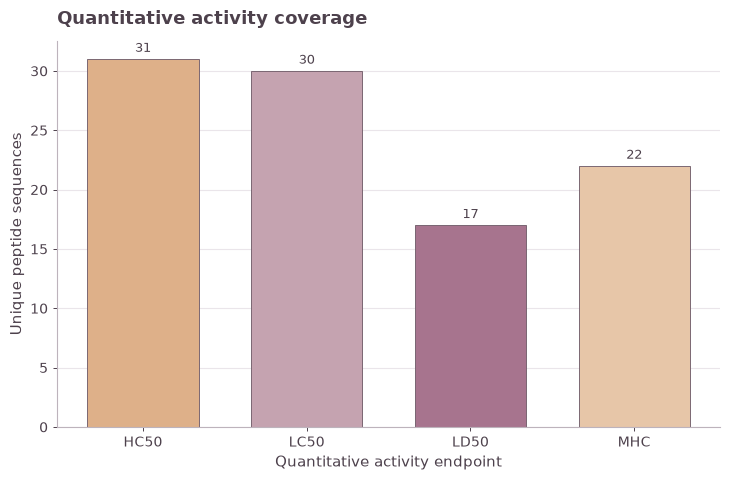

In [10]:
endpoint_counts = (
    eligible
    .groupby("endpoint")
    .agg(
        measurements=("label_numeric", "size"),
        unique_sequences=("sequence", "nunique"),
    )
    .reindex(["HC50", "LC50", "LD50", "MHC"])
    .fillna(0)
    .reset_index()
)

coverage_values = endpoint_counts["unique_sequences"].to_numpy()
fig, ax = plt.subplots(figsize=(7.4, 4.9))
bars = ax.bar(
    endpoint_counts["endpoint"],
    coverage_values,
    color=[QUANTITATIVE_COLORS[endpoint] for endpoint in endpoint_counts["endpoint"]],
    edgecolor=EDGE_COLOR,
    linewidth=0.65,
    width=0.68,
)
ax.bar_label(
    bars,
    labels=[f"{value:,.0f}" for value in coverage_values],
    padding=3,
    color=TEXT_COLOR,
    fontsize=9,
)
ax.set_xlabel("Quantitative activity endpoint")
ax.set_ylabel("Unique peptide sequences")
ax.set_title("Quantitative activity coverage", loc="left", pad=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
style_axes(ax)
fig.tight_layout()
save_figure(fig, "01_quantitative_endpoint_coverage")
plt.show()

## 6. Select one homogeneous regression target


In [11]:
if ENDPOINT_OVERRIDE is not None:
    selected_groups = group_summary.loc[
        group_summary["endpoint"].eq(str(ENDPOINT_OVERRIDE).upper())
    ].copy()

    if UNIT_OVERRIDE is not None:
        selected_groups = selected_groups.loc[
            selected_groups["unit"].eq(str(UNIT_OVERRIDE))
        ].copy()

    if selected_groups.empty:
        raise ValueError(
            "The requested ENDPOINT_OVERRIDE / UNIT_OVERRIDE combination "
            "was not found in the released quantitative datasets."
        )

    selected_group = selected_groups.iloc[0]
else:
    usable = group_summary.loc[
        group_summary["unique_sequences"] >= MINIMUM_UNIQUE_SEQUENCES
    ].copy()

    if usable.empty:
        raise ValueError(
            f"No endpoint/unit group contains at least "
            f"{MINIMUM_UNIQUE_SEQUENCES} unique sequences. "
            "Inspect quantitative_endpoint_unit_summary.tsv before changing "
            "MINIMUM_UNIQUE_SEQUENCES."
        )

    selected_group = usable.iloc[0]

SELECTED_ENDPOINT = selected_group["endpoint"]
SELECTED_UNIT = selected_group["unit"]

print("Selected endpoint:", SELECTED_ENDPOINT)
print("Selected unit    :", SELECTED_UNIT)
print("Unique sequences :", int(selected_group["unique_sequences"]))
print("Measurements     :", int(selected_group["measurements"]))


Selected endpoint: LC50
Selected unit    : µM
Unique sequences : 30
Measurements     : 30


## 7. Aggregate repeated measurements by exact sequence

The underlying parsing workflow intentionally preserves multiple quantitative measurements for the same peptide. For this minimal regression example, repeated measurements within the selected endpoint/unit combination are summarized by their **median**.

The number of measurements and contributing sources is retained for auditing.


In [12]:
selected_records = eligible.loc[
    eligible["endpoint"].eq(SELECTED_ENDPOINT)
    & eligible["unit"].eq(SELECTED_UNIT)
].copy()

aggregated = (
    selected_records
    .groupby("sequence", as_index=False)
    .agg(
        activity_value=("label_numeric", "median"),
        measurement_count=("label_numeric", "size"),
        source_count=("source", "nunique"),
        activity_min=("label_numeric", "min"),
        activity_max=("label_numeric", "max"),
    )
)

aggregated = aggregated.merge(
    sequence_to_id,
    on="sequence",
    how="left",
    validate="one_to_one",
)

mapping_summary = pd.DataFrame([{
    "selected_endpoint": SELECTED_ENDPOINT,
    "selected_unit": SELECTED_UNIT,
    "unique_sequences_before_id_mapping": len(aggregated),
    "mapped_to_maomao_id": int(aggregated["id"].notna().sum()),
    "unmapped_sequences": int(aggregated["id"].isna().sum()),
}])

display(mapping_summary)
mapping_summary.to_csv(
    TABLE_DIR / "quantitative_id_mapping_summary.tsv",
    sep="\t",
    index=False,
)

regression_data = aggregated.loc[aggregated["id"].notna()].copy()
regression_data["id"] = regression_data["id"].astype(str)
regression_data["log10_activity_value"] = np.log10(regression_data["activity_value"])

display(regression_data.head(15))

regression_data.to_csv(
    TABLE_DIR / "selected_quantitative_regression_dataset.tsv",
    sep="\t",
    index=False,
)


,selected_endpoint,selected_unit,unique_sequences_before_id_mapping,mapped_to_maomao_id,unmapped_sequences
0,LC50,µM,30,30,0


,sequence,activity_value,measurement_count,source_count,activity_min,activity_max,id,log10_activity_value
0,AAAKAALNAVLVGANA,40.000,1,1,40.000,40.000,sha256_ac92af50ce42fc29a5f93795b96e777e9382fc4562f01c4c0c8b1e521a4875df,1.602060
1,ALWMTLLKKVLK,100.000,1,1,100.000,100.000,sha256_cc1543b15fd6342f1e1a22088ef818d04627d84c08ea89176c4a551d4b049ff7,2.000000
2,FKDLKKIANIINSIFKK,1.186,1,1,1.186,1.186,sha256_f4e726ec5066b46b87cb40eccaa2d38fe1d1f318bfd3baafd0049e5835fe5471,0.074085
3,FKKLKKIANIINSIFKK,4.649,1,1,4.649,4.649,sha256_8483d2294d0da1d8048c53abd270124b0d78bfd7f809857d4c3c05fb62cbf94d,0.667360
4,FLPLLAGLAANFLPKIFCKITRKC,5.000,1,1,5.000,5.000,sha256_6f74e26d8a5270bf23fa95b517588aead9dc0cc30ffc202c7d924e1880f77a6e,0.698970
5,FVDLKKIANIINSIFGK,95.700,1,1,95.700,95.700,sha256_de2ffa157bff92cf134f34543855231f56f33856f49359379de01e2b2207add2,1.980912
6,FVDLKKIANIINSIFKK,1.467,1,1,1.467,1.467,sha256_55b2bc8a28425d267697d092d6cf45123add0e46917d066faa7707231aae81dd,0.166430
7,FVKLKKIANIINSIFKK,1.993,1,1,1.993,1.993,sha256_b52090444a37607c0805850edde564e5501ebb9427b948b5c2775afb878b6899,0.299507
8,FVKLKKILNIILSIFKK,28.340,1,1,28.340,28.340,sha256_88d8cfc0e8c105b159d91cda738e6aef1daa95966520e1eaa8c2b807b1e14a43,1.452400
9,FVKLKKILNIINSIFKK,86.990,1,1,86.990,86.990,sha256_57208de2de8a2df964967f12c18bd0801863fb5b0e711bde6649548413f5e783,1.939469


## 8. Inspect the selected activity-value distribution


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/02_selected_activity_distribution.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/02_selected_activity_distribution.pdf


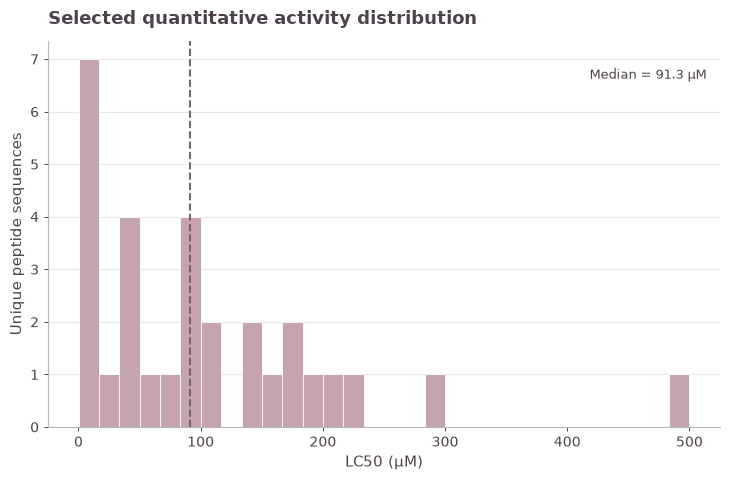

In [13]:
selected_color = QUANTITATIVE_COLORS.get(SELECTED_ENDPOINT, COLORS["toxic"])
median_activity = float(regression_data["activity_value"].median())

fig, ax = plt.subplots(figsize=(7.4, 4.9))
ax.hist(
    regression_data["activity_value"],
    bins=30,
    color=selected_color,
    edgecolor="white",
    linewidth=0.6,
)
ax.axvline(median_activity, color=EDGE_COLOR, linestyle="--", linewidth=1.4)
ax.text(
    0.98,
    0.93,
    f"Median = {median_activity:,.3g} {SELECTED_UNIT}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    color=TEXT_COLOR,
    fontsize=9.3,
)
ax.set_xlabel(f"{SELECTED_ENDPOINT} ({SELECTED_UNIT})")
ax.set_ylabel("Unique peptide sequences")
ax.set_title("Selected quantitative activity distribution", loc="left", pad=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
style_axes(ax)
fig.tight_layout()
save_figure(fig, "02_selected_activity_distribution")
plt.show()

Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/03_log10_target_distribution.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/03_log10_target_distribution.pdf


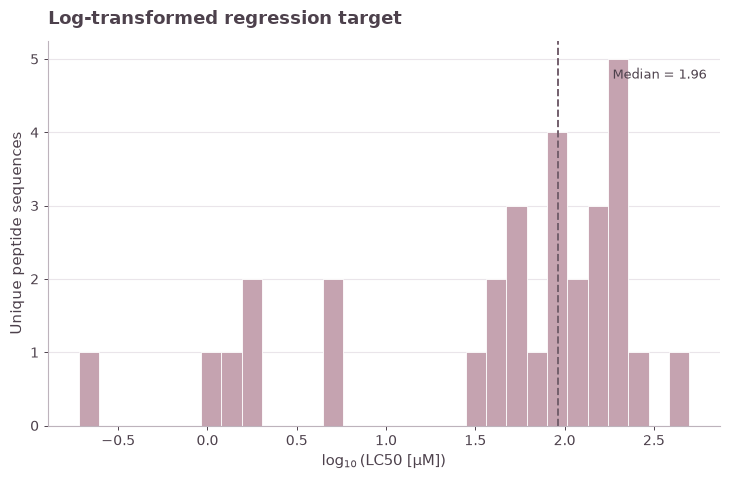

In [14]:
median_log_activity = float(regression_data["log10_activity_value"].median())

fig, ax = plt.subplots(figsize=(7.4, 4.9))
ax.hist(
    regression_data["log10_activity_value"],
    bins=30,
    color=selected_color,
    edgecolor="white",
    linewidth=0.6,
)
ax.axvline(median_log_activity, color=EDGE_COLOR, linestyle="--", linewidth=1.4)
ax.text(
    0.98,
    0.93,
    f"Median = {median_log_activity:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    color=TEXT_COLOR,
    fontsize=9.3,
)
ax.set_xlabel(rf"$\log_{{10}}$({SELECTED_ENDPOINT} [{SELECTED_UNIT}])")
ax.set_ylabel("Unique peptide sequences")
ax.set_title("Log-transformed regression target", loc="left", pad=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
style_axes(ax)
fig.tight_layout()
save_figure(fig, "03_log10_target_distribution")
plt.show()

## 9. Join one released PLM representation

The same stable MAOMAO `id` used in the master pivot connects the selected quantitative sequences to released numerical representations.


In [15]:
ENDPOINTS = [
    "toxic", "cytotoxic", "hemolytic", "cytolysis",
    "neurotoxic", "embryotoxic", "ichthyotoxic",
]

PREFERRED_REPRESENTATIONS = [
    "esm2_t6_8M_UR50D",
    "ankh2_ext1",
    "esm2_t12_35M_UR50D",
    "esm2_t30_150M_UR50D",
]

NON_FEATURE_COLUMNS = {
    "id", "sequence", "label", "sequence_length",
    *ENDPOINTS,
}

def find_representation_root(root):
    candidates = [
        root / "numerical_representation_data" / "maomao" / "sylphy_embedding",
        root / "embedding_layer" / "numerical_representation_data" / "maomao" / "sylphy_embedding",
    ]
    return next((p for p in candidates if p.is_dir()), None)

def select_representation_file(root):
    rep_root = find_representation_root(root)
    if rep_root is None:
        raise FileNotFoundError(
            "Could not find numerical_representation_data/maomao/sylphy_embedding. "
            "Restore/download the MAOMAO Embedding Layer."
        )

    for alias in PREFERRED_REPRESENTATIONS:
        path = rep_root / alias / "full_data.csv"
        if path.is_file():
            return alias, path

    available = sorted(rep_root.glob("*/full_data.csv"))
    if not available:
        raise FileNotFoundError(f"No full_data.csv files found under {rep_root}")

    return available[0].parent.name, available[0]

def discover_feature_columns(path):
    header = pd.read_csv(path, nrows=0)
    columns = list(header.columns)

    indexed = []
    for col in columns:
        match = re.fullmatch(r"p_(\d+)", str(col))
        if match:
            indexed.append((int(match.group(1)), col))

    if indexed:
        indexed.sort()
        return [col for _, col in indexed], "p_<integer>"

    sample = pd.read_csv(path, nrows=100)
    numeric = [
        col for col in sample.columns
        if pd.api.types.is_numeric_dtype(sample[col])
        and col not in NON_FEATURE_COLUMNS
    ]
    if not numeric:
        raise ValueError(
            "No numerical representation columns were identified. "
            "Inspect the representation schema before continuing."
        )
    return numeric, "numeric fallback"

def load_representation_for_ids(path, ids, feature_columns, chunksize=20000):
    ids = set(map(str, ids))
    pieces = []

    for chunk in pd.read_csv(
        path,
        usecols=["id", *feature_columns],
        chunksize=chunksize,
    ):
        mask = chunk["id"].astype(str).isin(ids)
        if mask.any():
            pieces.append(chunk.loc[mask].copy())

    if not pieces:
        return pd.DataFrame(columns=["id", *feature_columns])

    out = pd.concat(pieces, ignore_index=True)
    out["id"] = out["id"].astype(str)
    return out.drop_duplicates(subset="id")


In [16]:
representation_name, representation_path = select_representation_file(MAOMAO_ROOT)
feature_columns, feature_contract = discover_feature_columns(representation_path)

representation = load_representation_for_ids(
    representation_path,
    regression_data["id"],
    feature_columns,
)

dataset = regression_data.merge(
    representation,
    on="id",
    how="inner",
    validate="one_to_one",
)

coverage = len(dataset) / len(regression_data) if len(regression_data) else np.nan

print("Representation            :", representation_name)
print("Feature contract          :", feature_contract)
print("Number of features        :", len(feature_columns))
print("Quantitative sequences    :", len(regression_data))
print("Represented sequences     :", len(dataset))
print("Representation coverage   :", f"{coverage:.1%}")

if len(dataset) < MINIMUM_UNIQUE_SEQUENCES:
    raise ValueError(
        "Too few represented sequences remain for the illustrative regression."
    )


Representation            : esm2_t6_8M_UR50D
Feature contract          : p_<integer>
Number of features        : 320
Quantitative sequences    : 30
Represented sequences     : 30
Representation coverage   : 100.0%


## 10. Create a reproducible regression split

If a dedicated quantitative split layer is added to MAOMAO in a future release, this section can be replaced by direct reuse of those split IDs.

For the current worked example, a deterministic 80/20 split is created **only for the selected homogeneous quantitative subset**. The random state is recorded explicitly.


In [17]:
train_df, test_df = train_test_split(
    dataset,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_train = train_df[feature_columns].to_numpy(dtype=np.float32)
X_test = test_df[feature_columns].to_numpy(dtype=np.float32)

y_train = train_df["log10_activity_value"].to_numpy(dtype=float)
y_test = test_df["log10_activity_value"].to_numpy(dtype=float)

split_summary = pd.DataFrame([{
    "endpoint": SELECTED_ENDPOINT,
    "unit": SELECTED_UNIT,
    "representation": representation_name,
    "target": "log10(activity_value)",
    "n_total": len(dataset),
    "n_train": len(train_df),
    "n_test": len(test_df),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
}])

display(split_summary)
split_summary.to_csv(
    TABLE_DIR / "regression_split_summary.tsv",
    sep="\t",
    index=False,
)


,endpoint,unit,representation,target,n_total,n_train,n_test,test_size,random_state
0,LC50,µM,esm2_t6_8M_UR50D,log10(activity_value),30,24,6,0.2,42


## 11. Compare a baseline and a simple Ridge model

A median `DummyRegressor` provides a minimal baseline. The Ridge model uses standardized PLM features and a fixed `alpha=1.0`.

No hyperparameter optimization is performed.


In [18]:
models = {
    "median_baseline": DummyRegressor(strategy="median"),
    "ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Ridge(alpha=1.0)),
    ]),
}

for name, model in models.items():
    print("Fitting:", name)
    model.fit(X_train, y_train)


Fitting: median_baseline
Fitting: ridge


## 12. Evaluate the test partition


In [19]:
metric_rows = []
prediction_tables = {}

for name, model in models.items():
    pred = model.predict(X_test)

    rho, rho_p = spearmanr(y_test, pred)

    metric_rows.append({
        "model": name,
        "endpoint": SELECTED_ENDPOINT,
        "unit": SELECTED_UNIT,
        "target": "log10(activity_value)",
        "n_test": len(y_test),
        "mae_log10": mean_absolute_error(y_test, pred),
        "rmse_log10": mean_squared_error(y_test, pred) ** 0.5,
        "r2": r2_score(y_test, pred),
        "spearman_rho": rho,
        "spearman_p_value": rho_p,
    })

    predictions = test_df[
        ["id", "sequence", "activity_value", "log10_activity_value"]
    ].copy()
    predictions["predicted_log10_activity_value"] = pred
    predictions["predicted_activity_value"] = np.power(10.0, pred)

    prediction_tables[name] = predictions

metrics = pd.DataFrame(metric_rows)
display(metrics)

metrics.to_csv(TABLE_DIR / "regression_metrics.tsv", sep="\t", index=False)

for name, predictions in prediction_tables.items():
    predictions.to_csv(
        TABLE_DIR / f"test_predictions_{name}.tsv",
        sep="\t",
        index=False,
    )


/tmp/ipykernel_75449/1218891488.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, rho_p = spearmanr(y_test, pred)


,model,endpoint,unit,target,n_test,mae_log10,rmse_log10,r2,spearman_rho,spearman_p_value
0,median_baseline,LC50,µM,log10(activity_value),6,0.327015,0.412230,-0.029544,NaN,NaN
1,ridge,LC50,µM,log10(activity_value),6,1.145851,1.392869,-10.754024,0.314286,0.544093


## 13. Observed vs predicted values for Ridge regression


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/04_ridge_observed_vs_predicted.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/04_ridge_observed_vs_predicted.pdf


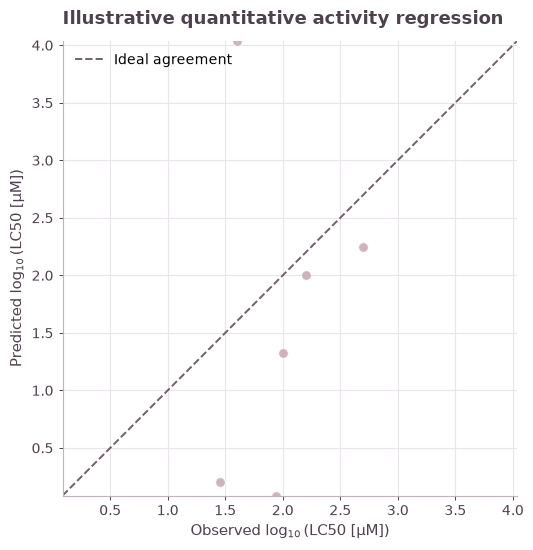

In [20]:
ridge_predictions = prediction_tables["ridge"]

observed = ridge_predictions["log10_activity_value"].to_numpy()
predicted = ridge_predictions["predicted_log10_activity_value"].to_numpy()

low = min(float(np.min(observed)), float(np.min(predicted)))
high = max(float(np.max(observed)), float(np.max(predicted)))

fig, ax = plt.subplots(figsize=(6.1, 5.6))
ax.scatter(
    observed,
    predicted,
    s=48,
    alpha=0.82,
    color=selected_color,
    edgecolor="white",
    linewidth=0.65,
)
ax.plot(
    [low, high],
    [low, high],
    color=EDGE_COLOR,
    linestyle="--",
    linewidth=1.4,
    label="Ideal agreement",
)
ax.set_xlim(low, high)
ax.set_ylim(low, high)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(rf"Observed $\log_{{10}}$({SELECTED_ENDPOINT} [{SELECTED_UNIT}])")
ax.set_ylabel(rf"Predicted $\log_{{10}}$({SELECTED_ENDPOINT} [{SELECTED_UNIT}])")
ax.set_title("Illustrative quantitative activity regression", loc="left", pad=12)
ax.legend(loc="upper left")
style_axes(ax, grid_axis="both")
fig.tight_layout()
save_figure(fig, "04_ridge_observed_vs_predicted")
plt.show()

## 14. Ridge residual distribution


,mean_residual_log10,median_residual_log10,residual_std_log10
0,-0.333295,-0.566462,1.481486


Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/05_ridge_residual_distribution.png
Saved: /home/nicole/Descargas/maomao/results_how_to_use_maomao/03_quantitative_activity_regression/figures/05_ridge_residual_distribution.pdf


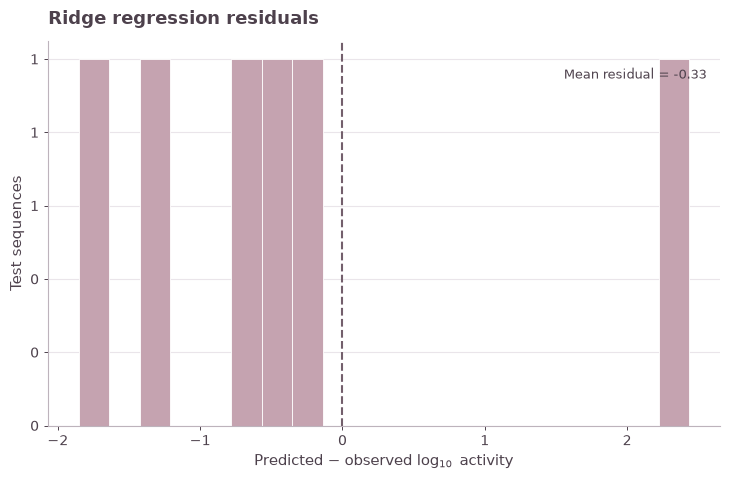

In [21]:
residuals = predicted - observed

residual_summary = pd.DataFrame([{
    "mean_residual_log10": float(np.mean(residuals)),
    "median_residual_log10": float(np.median(residuals)),
    "residual_std_log10": float(np.std(residuals, ddof=1)) if len(residuals) > 1 else np.nan,
}])

display(residual_summary)
residual_summary.to_csv(
    TABLE_DIR / "ridge_residual_summary.tsv",
    sep="\t",
    index=False,
)

fig, ax = plt.subplots(figsize=(7.4, 4.9))
ax.hist(
    residuals,
    bins=20,
    color=selected_color,
    edgecolor="white",
    linewidth=0.6,
)
ax.axvline(0, color=EDGE_COLOR, linestyle="--", linewidth=1.5)
ax.text(
    0.98,
    0.93,
    f"Mean residual = {np.mean(residuals):.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    color=TEXT_COLOR,
    fontsize=9.3,
)
ax.set_xlabel(r"Predicted − observed $\log_{10}$ activity")
ax.set_ylabel("Test sequences")
ax.set_title("Ridge regression residuals", loc="left", pad=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
style_axes(ax)
fig.tight_layout()
save_figure(fig, "05_ridge_residual_distribution")
plt.show()

## 15. Record analysis metadata


In [22]:
analysis_metadata = pd.DataFrame([{
    "endpoint": SELECTED_ENDPOINT,
    "unit": SELECTED_UNIT,
    "representation": representation_name,
    "feature_contract": feature_contract,
    "n_features": len(feature_columns),
    "repeated_measurement_aggregation": "median by exact sequence",
    "target_transform": "log10",
    "modified_peptides_included": False,
    "models": "median_baseline; ridge_alpha_1",
    "hyperparameter_optimization": False,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
}])

display(analysis_metadata)

analysis_metadata.to_csv(
    TABLE_DIR / "analysis_metadata.tsv",
    sep="\t",
    index=False,
)


,endpoint,unit,representation,feature_contract,n_features,repeated_measurement_aggregation,target_transform,modified_peptides_included,models,hyperparameter_optimization,test_size,random_state
0,LC50,µM,esm2_t6_8M_UR50D,p_<integer>,320,median by exact sequence,log10,False,median_baseline; ridge_alpha_1,False,0.2,42
